In [40]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE

from build_finesat_dataset import build_finesat_dataset

In [41]:
DATASET_DIR = os.path.join('..', 'geometry-consistent-data')
FILENAME = "gc_c3.2_data1.json"
RTCM_PATH = os.path.join(os.getcwd(), "..", "..", "gnss-data-collection",
                         "window-experiment", "data", "samples")

with open(os.path.join(DATASET_DIR, FILENAME), 'r') as f:
    data = json.load(f)

In [42]:
window0_data_paths = []
window0 = data[0]
for i in range(0, len(window0)):
    window0_data_paths.append(os.path.join(RTCM_PATH, window0[i][0]))

window1_data_paths = []
window1 = data[1]
for i in range(0, len(window1)):
    window1_data_paths.append(os.path.join(RTCM_PATH, window1[i][0]))

window2_data_paths = []
window2 = data[2]
for i in range(0, len(window2)):
    window2_data_paths.append(os.path.join(RTCM_PATH, window2[i][0]))

window3_data_paths = []
window3 = data[3]
for i in range(0, len(window3)):
    window3_data_paths.append(os.path.join(RTCM_PATH, window3[i][0]))

In [43]:
X0_fs, Y0_fs = build_finesat_dataset(window0_data_paths)
X1_fs, Y1_fs = build_finesat_dataset(window1_data_paths)
X2_fs, Y2_fs = build_finesat_dataset(window2_data_paths)
X3_fs, Y3_fs = build_finesat_dataset(window3_data_paths)

Processing 46 files for FINESAT Pipeline...

FineSat Dataset Built!
Feature Matrix (X) Shape: (46, 78)  -> (46 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (46,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 60 files for FINESAT Pipeline...

FineSat Dataset Built!
Feature Matrix (X) Shape: (60, 78)  -> (60 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (60,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 90 files for FINESAT Pipeline...


Unknown protocol header b'\xd3m'.
Unknown protocol header b'$\x04'.
Unknown protocol header b'\xd3\x80'.
Unknown protocol header b'$x'.
Unknown protocol header b'\xb5\xfa'.
Unknown protocol header b'\xd3D'.
Unknown protocol header b'\xd3w'.
Unknown protocol header b'$\x06'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5\xfa'.
Unknown protocol header b'$\xe2'.
Unknown protocol header b'$;'.
Unknown protocol header b'$\t'.
Unknown protocol header b'\xb5 '.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xd3\xd7'.
Unknown protocol header b'\xb5\x9f'.
Unknown protocol header b'\xd3Z'.
Unknown protocol header b'\xd3\xde'.
Unknown protocol header b'\xb5\x9b'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5^'.
Unknown protocol header b'\xd3\x9d'.
Serial stream terminated unexpectedly. 1874 bytes requested, 955 bytes returned.
Unknown protocol header b'$K'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x95'.
Unknown protocol heade


FineSat Dataset Built!
Feature Matrix (X) Shape: (90, 78)  -> (90 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (90,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 78 files for FINESAT Pipeline...


Unknown protocol header b'\xb5\x8b'.
Serial stream terminated unexpectedly. 170 bytes requested, 126 bytes returned.
Unknown protocol header b'$g'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5\x8a'.
Unknown protocol header b'\xb5\x97'.
Unknown protocol header b'\xd3\xed'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xd3\xf7'.
Unknown protocol header b'$0'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x05'.



FineSat Dataset Built!
Feature Matrix (X) Shape: (78, 78)  -> (78 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (78,)
Saved as ./X_finesat.npy and ./Y_finesat.npy


In [44]:
# Encoding labels
label_encoder_fs = LabelEncoder()
Y0_encoded_fs = label_encoder_fs.fit_transform(Y0_fs)
Y1_encoded_fs = label_encoder_fs.fit_transform(Y1_fs)
Y2_encoded_fs = label_encoder_fs.fit_transform(Y2_fs)
Y3_encoded_fs = label_encoder_fs.fit_transform(Y3_fs)

In [45]:
# train-test split: 80-20 ratio
X0_train_fs, X0_test_fs, Y0_train_fs, Y0_test_fs = train_test_split(
    X0_fs, Y0_encoded_fs, test_size=0.2, random_state=42, stratify=Y0_encoded_fs
)

X1_train_fs, X1_test_fs, Y1_train_fs, Y1_test_fs = train_test_split(
    X1_fs, Y1_encoded_fs, test_size=0.2, random_state=42, stratify=Y1_encoded_fs
)

X2_train_fs, X2_test_fs, Y2_train_fs, Y2_test_fs = train_test_split(
    X2_fs, Y2_encoded_fs, test_size=0.2, random_state=42, stratify=Y2_encoded_fs
)

X3_train_fs, X3_test_fs, Y3_train_fs, Y3_test_fs = train_test_split(
    X3_fs, Y3_encoded_fs, test_size=0.2, random_state=42, stratify=Y3_encoded_fs
)

In [46]:
# Scale features (Mean=0, Variance=1)
scaler_fs = StandardScaler()

X0_train_scaled_fs = scaler_fs.fit_transform(X0_train_fs)
X0_test_scaled_fs = scaler_fs.transform(X0_test_fs)

X1_train_scaled_fs = scaler_fs.fit_transform(X1_train_fs)
X1_test_scaled_fs = scaler_fs.transform(X1_test_fs)

X2_train_scaled_fs = scaler_fs.fit_transform(X2_train_fs)
X2_test_scaled_fs = scaler_fs.transform(X2_test_fs)

X3_train_scaled_fs = scaler_fs.fit_transform(X3_train_fs)
X3_test_scaled_fs = scaler_fs.transform(X3_test_fs)

In [47]:
tsne_fs = TSNE(n_components=2, random_state=42)

X0_embedded_fs = tsne_fs.fit_transform(X0_train_scaled_fs)
X1_embedded_fs = tsne_fs.fit_transform(X1_train_scaled_fs)
X2_embedded_fs = tsne_fs.fit_transform(X2_train_scaled_fs)
X3_embedded_fs = tsne_fs.fit_transform(X3_train_scaled_fs)

In [57]:
X3_embedded_fs.shape

(62, 2)

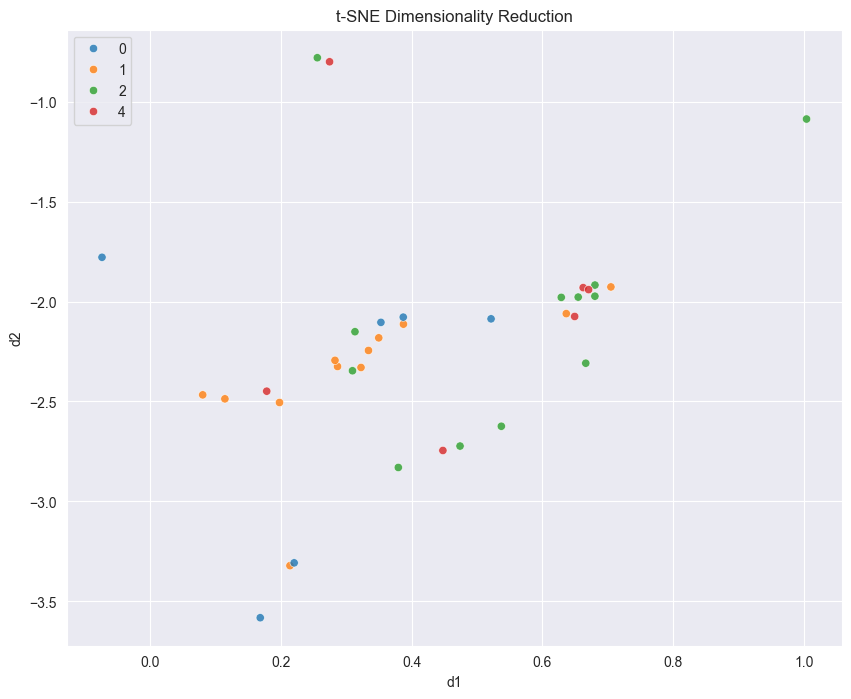

In [52]:
# Plotting samples in 2d
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X0_embedded_fs[:,0],
    y=X0_embedded_fs[:,1],
    hue=Y0_encoded_fs[:36],
    palette="tab10",
    legend="full",
    alpha=0.8,
)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("d1")
plt.ylabel("d2")
plt.show()

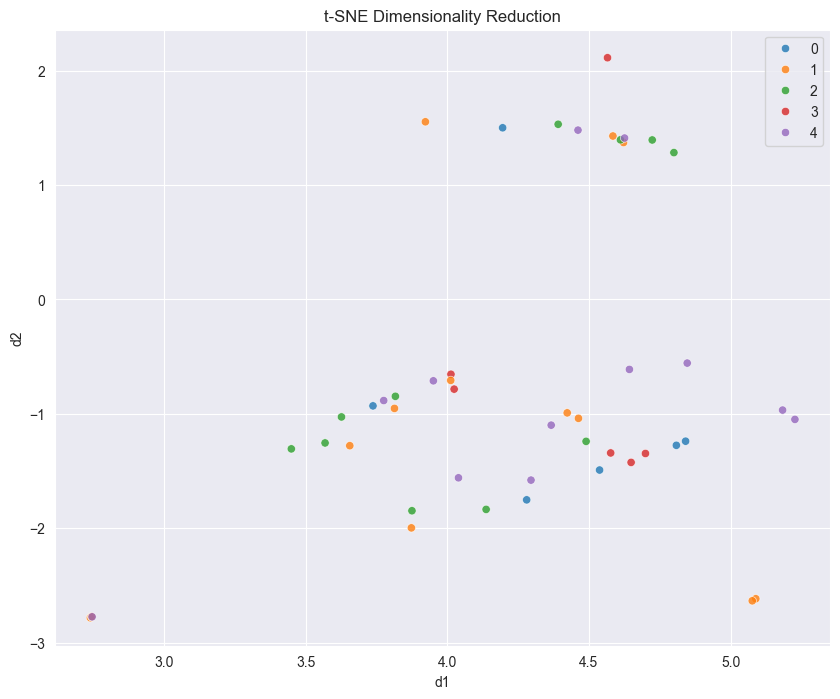

In [54]:
# Plotting samples in 2d
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X1_embedded_fs[:,0],
    y=X1_embedded_fs[:,1],
    hue=Y1_encoded_fs[:48],
    palette="tab10",
    legend="full",
    alpha=0.8,
)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("d1")
plt.ylabel("d2")
plt.show()

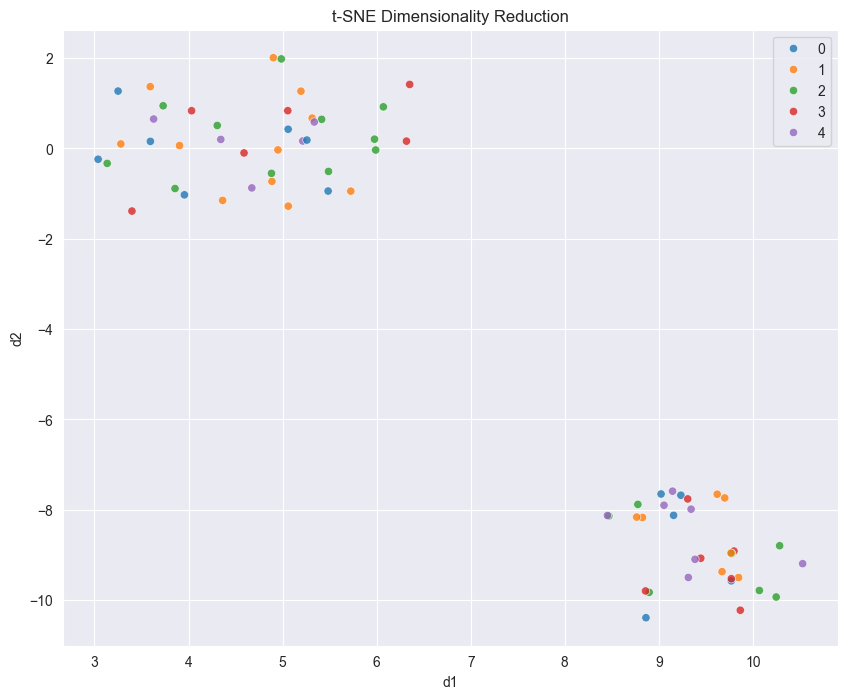

In [56]:
# Plotting samples in 2d
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X2_embedded_fs[:,0],
    y=X2_embedded_fs[:,1],
    hue=Y2_encoded_fs[:72],
    palette="tab10",
    legend="full",
    alpha=0.8,
)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("d1")
plt.ylabel("d2")
plt.show()

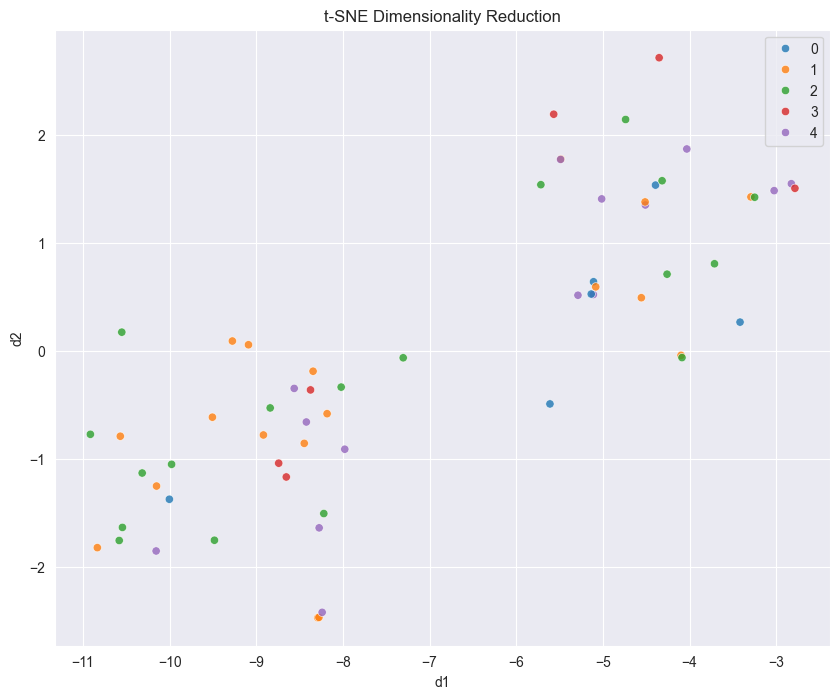

In [58]:
# Plotting samples in 2d
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X3_embedded_fs[:,0],
    y=X3_embedded_fs[:,1],
    hue=Y3_encoded_fs[:62],
    palette="tab10",
    legend="full",
    alpha=0.8,
)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("d1")
plt.ylabel("d2")
plt.show()